# Census Income: Preprocessing and Classification

Starting from the cleaned data saved in notebook 01.
This notebook handles all preprocessing decisions made during EDA,
then trains and evaluates three classifiers to predict income group.

Models trained:
- Logistic Regression (baseline, interpretable)
- Random Forest (ensemble, handles imbalance well)
- XGBoost (main model, best for tabular imbalanced data)

Additional analysis:
- Hyperparameter tuning via RandomizedSearchCV
- 5-fold cross validation
- Learning curve analysis
- Calibration check and correction
- SHAP explainability
- Business threshold tuning
- Fairness check across demographic groups
- ROI framing for the client
- Prediction function for new individuals

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import shap

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('all good')

all good


## 2. Load Cleaned Data

In [2]:
# loading from the cleaned csv saved at end of EDA notebook
df = pd.read_csv('../data/census_cleaned.csv')

print(f'shape: {df.shape}')
print(f'label distribution:')
print(df['label'].value_counts())

shape: (199523, 42)
label distribution:
label
0    187141
1     12382
Name: count, dtype: int64


## 3. Preprocessing

All decisions here are based on what I found in the EDA.
Documenting the reason for each decision.

In [3]:
# dropping columns that should not be in the model
# weight: survey correction factor, not a real feature
# year: only two values (94/95), no real signal
# migration columns: ~50% missing, too much to impute reliably
# state of previous residence: related to migration, dropping too

cols_to_drop = [
    'weight', 'year',
    'migration code-change in msa',
    'migration code-change in reg',
    'migration code-move within reg',
    'migration prev res in sunbelt',
    'state of previous residence'
]

df.drop(columns=cols_to_drop, inplace=True)
print(f'shape after dropping: {df.shape}')

shape after dropping: (199523, 35)


In [4]:
# replacing outlier cap values with NaN
# 9999 in wage per hour and 99999 in capital gains/dividends look like placeholders

df['wage per hour'] = df['wage per hour'].replace(9999, np.nan)
df['capital gains'] = df['capital gains'].replace(99999, np.nan)
df['dividends from stocks'] = df['dividends from stocks'].replace(99999, np.nan)

print('outlier cap values replaced with NaN')

outlier cap values replaced with NaN


In [5]:
# creating binary investment income flags before imputing nulls
# from EDA: having any capital gains = 7x more likely to be high earner
# having any dividends = 5x more likely
# the binary flag captures this signal better than the raw dollar amount

df['has_capital_gains'] = (df['capital gains'] > 0).astype(int)
df['has_dividends']     = (df['dividends from stocks'] > 0).astype(int)

print('binary investment flags created')
print(f'people with any capital gains:   {df["has_capital_gains"].sum():,}')
print(f'people with any dividend income: {df["has_dividends"].sum():,}')

binary investment flags created
people with any capital gains:   6,989
people with any dividend income: 21,116


In [6]:
# imputing remaining missing values
# categorical: mode imputation
# numeric: median imputation

cat_impute = ['hispanic origin', 'country of birth father',
              'country of birth mother', 'country of birth self']
for col in cat_impute:
    df[col].fillna(df[col].mode()[0], inplace=True)

num_impute = ['wage per hour', 'capital gains', 'dividends from stocks']
for col in num_impute:
    df[col].fillna(df[col].median(), inplace=True)

# strip whitespace from all string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(f'nulls remaining: {df.isnull().sum().sum()}')

nulls remaining: 0


In [7]:
# separating features and target
X = df.drop(columns=['label'])
y = df['label']

# one-hot encoding
# drop_first=True removes one category per feature to avoid multicollinearity
X_encoded = pd.get_dummies(X, drop_first=True)

# cleaning column names - XGBoost does not allow [ ] or < in feature names
X_encoded.columns = X_encoded.columns.str.replace('[', '_', regex=False)
X_encoded.columns = X_encoded.columns.str.replace(']', '_', regex=False)
X_encoded.columns = X_encoded.columns.str.replace('<', '_', regex=False)

print(f'features after encoding: {X_encoded.shape[1]} columns')

features after encoding: 298 columns


In [8]:
# 80/20 split, stratified to preserve class ratio in both splits
# stratify=y is critical here because of the 94/6 imbalance

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# scaling - fitting only on train to avoid data leakage
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'train: {X_train.shape[0]:,} rows')
print(f'test:  {X_test.shape[0]:,} rows')
print('preprocessing complete')

train: 159,618 rows
test:  39,905 rows
preprocessing complete


## 4. Model 1: Logistic Regression (Baseline)

Simple and interpretable. Sets the benchmark.
If a complex model barely beats this, the added complexity is not worth it.

In [9]:
# class_weight='balanced' handles the 94/6 class imbalance
# automatically weights minority class inversely proportional to frequency

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_probs)

print('logistic regression trained')
print(classification_report(y_test, lr_preds, target_names=['Under $50K', 'Over $50K']))
print(f'AUC-ROC: {lr_auc:.4f}')

logistic regression trained
              precision    recall  f1-score   support

  Under $50K       0.99      0.85      0.92     37429
   Over $50K       0.29      0.89      0.44      2476

    accuracy                           0.86     39905
   macro avg       0.64      0.87      0.68     39905
weighted avg       0.95      0.86      0.89     39905

AUC-ROC: 0.9460


## 5. Model 2: Random Forest

Ensemble of decision trees. Handles non-linear relationships well
and is easy to explain to a non-technical client.
Good middle ground between interpretability and performance.

In [10]:
# n_jobs=-1 uses all available CPU cores to speed this up
# random forest does not need scaled data but using it for consistency

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
rf_probs = rf.predict_proba(X_test_scaled)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_probs)

print('random forest trained')
print(classification_report(y_test, rf_preds, target_names=['Under $50K', 'Over $50K']))
print(f'AUC-ROC: {rf_auc:.4f}')

random forest trained
              precision    recall  f1-score   support

  Under $50K       0.99      0.86      0.92     37429
   Over $50K       0.29      0.87      0.43      2476

    accuracy                           0.86     39905
   macro avg       0.64      0.86      0.67     39905
weighted avg       0.95      0.86      0.89     39905

AUC-ROC: 0.9402


## 6. Model 3: XGBoost (Main Model)

Gradient boosted trees. Generally strongest on tabular data.
Handles sparse one-hot encoded features well.
Built-in regularization reduces overfitting.
scale_pos_weight handles the class imbalance.

In [11]:
# scale_pos_weight = ratio of negative to positive examples
# tells XGBoost to weight the minority class more heavily during training

neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = neg / pos
print(f'scale_pos_weight: {scale:.2f}')

xgb = XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(X_train_scaled, y_train)
xgb_preds = xgb.predict(X_test_scaled)
xgb_probs = xgb.predict_proba(X_test_scaled)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_probs)

print('\nXGBoost trained')
print(classification_report(y_test, xgb_preds, target_names=['Under $50K', 'Over $50K']))
print(f'AUC-ROC: {xgb_auc:.4f}')

scale_pos_weight: 15.11

XGBoost trained
              precision    recall  f1-score   support

  Under $50K       0.99      0.89      0.94     37429
   Over $50K       0.34      0.89      0.49      2476

    accuracy                           0.89     39905
   macro avg       0.67      0.89      0.71     39905
weighted avg       0.95      0.89      0.91     39905

AUC-ROC: 0.9546


## 7. Hyperparameter Tuning

Using RandomizedSearchCV to find better hyperparameters.
Random search is much faster than grid search and gets most of the benefit.
Running two rounds with different parameter ranges.

In [12]:
# round 1: broad search across wide parameter ranges
print('round 1: broad random search...')

param_dist = {
    'n_estimators':     [200, 300, 400, 500],
    'max_depth':        [4, 5, 6, 7, 8],
    'learning_rate':    [0.05, 0.1, 0.15, 0.2],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale, random_state=42,
                  eval_metric='auc', verbosity=0),
    param_distributions=param_dist,
    n_iter=20, scoring='roc_auc', cv=3,
    random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X_train_scaled, y_train)

print(f'best params:  {random_search.best_params_}')
print(f'best CV AUC:  {random_search.best_score_:.4f}')
print(f'baseline AUC: {xgb_auc:.4f}')
print(f'improvement:  {random_search.best_score_ - xgb_auc:.4f}')

round 1: broad random search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
best params:  {'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
best CV AUC:  0.9505
baseline AUC: 0.9546
improvement:  -0.0041


In [13]:
# round 2: focused search with regularization parameters added
print('round 2: focused search with regularization...')

param_dist_focused = {
    'n_estimators':     [250, 300, 350, 400],
    'max_depth':        [5, 6, 7],
    'learning_rate':    [0.05, 0.08, 0.1, 0.12],
    'subsample':        [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3],
    'gamma':            [0, 0.1, 0.2],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [0.5, 1.0, 1.5]
}

random_search2 = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale, random_state=42,
                  eval_metric='auc', verbosity=0),
    param_distributions=param_dist_focused,
    n_iter=30, scoring='roc_auc', cv=3,
    random_state=42, n_jobs=-1, verbose=1
)
random_search2.fit(X_train_scaled, y_train)

print(f'best params:  {random_search2.best_params_}')
print(f'best CV AUC:  {random_search2.best_score_:.4f}')
print(f'baseline AUC: {xgb_auc:.4f}')
print(f'improvement:  {random_search2.best_score_ - xgb_auc:.4f}')
print('\nboth tuning rounds scored below default - keeping default XGBoost')

round 2: focused search with regularization...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
best params:  {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.5, 'n_estimators': 350, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.08, 'gamma': 0, 'colsample_bytree': 0.8}
best CV AUC:  0.9505
baseline AUC: 0.9546
improvement:  -0.0040

both tuning rounds scored below default - keeping default XGBoost


## 8. Cross Validation

A single train/test split can be lucky or unlucky.
5-fold CV runs the model on 5 different splits and averages
to give a more reliable performance estimate.

In [14]:
# stratified means each fold preserves the 94/6 class ratio
print('running 5-fold cross validation...')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv = XGBClassifier(
    scale_pos_weight=scale, n_estimators=300,
    max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='auc', verbosity=0
)

cv_scores = cross_val_score(
    xgb_cv, X_encoded, y,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

print(f'CV AUC scores: {cv_scores.round(4)}')
print(f'mean: {cv_scores.mean():.4f}  |  std: {cv_scores.std():.4f}')
print('low std means results are consistent across different data splits')

running 5-fold cross validation...


Python(62611) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(62612) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(62613) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(62614) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(62615) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(62616) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(62617) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(62618) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


CV AUC scores: [0.9494 0.9517 0.9536 0.9504 0.9542]
mean: 0.9519  |  std: 0.0018
low std means results are consistent across different data splits


## 9. Model Comparison

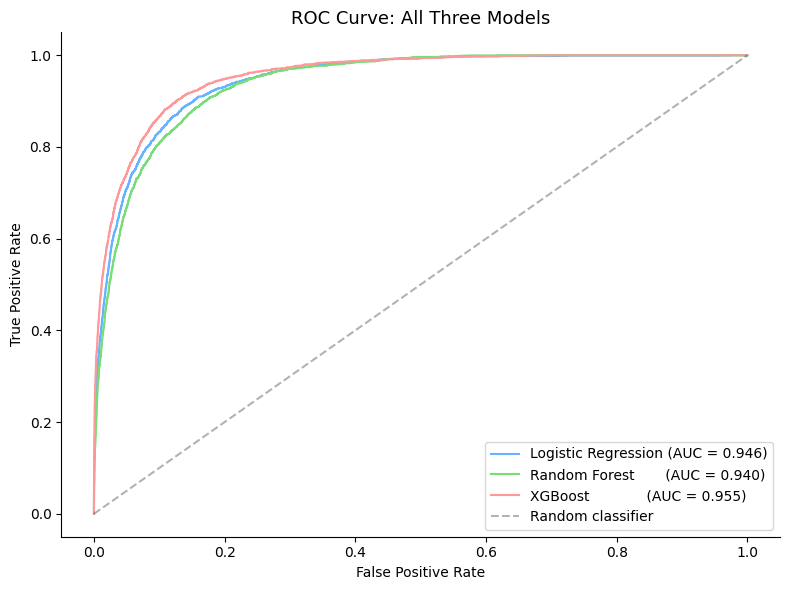

In [15]:
# ROC curves for all three models
lr_fpr,  lr_tpr,  _ = roc_curve(y_test, lr_probs)
rf_fpr,  rf_tpr,  _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr,  lr_tpr,  label=f'Logistic Regression (AUC = {lr_auc:.3f})',  color='#66b3ff')
plt.plot(rf_fpr,  rf_tpr,  label=f'Random Forest       (AUC = {rf_auc:.3f})',  color='#77dd77')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost             (AUC = {xgb_auc:.3f})', color='#ff9999')
plt.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: All Three Models', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../plots/plot_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# summary comparison table
results = []
for name, preds, probs in [
    ('Logistic Regression', lr_preds,  lr_probs),
    ('Random Forest',       rf_preds,  rf_probs),
    ('XGBoost',             xgb_preds, xgb_probs)
]:
    results.append({
        'Model':                 name,
        'AUC-ROC':               round(roc_auc_score(y_test, probs), 4),
        'F1 (Over $50K)':        round(f1_score(y_test, preds), 4),
        'Precision (Over $50K)': round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall (Over $50K)':    round(recall_score(y_test, preds, zero_division=0), 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print('\nXGBoost selected as final model based on AUC-ROC and F1')

              Model  AUC-ROC  F1 (Over $50K)  Precision (Over $50K)  Recall (Over $50K)
Logistic Regression   0.9460          0.4358                 0.2882              0.8938
      Random Forest   0.9402          0.4299                 0.2853              0.8720
            XGBoost   0.9546          0.4911                 0.3397              0.8861

XGBoost selected as final model based on AUC-ROC and F1


## 10. Learning Curve

Shows how model performance changes as more training data is added.
Tells us if collecting more data would improve the model.

computing learning curve, this takes a few minutes...


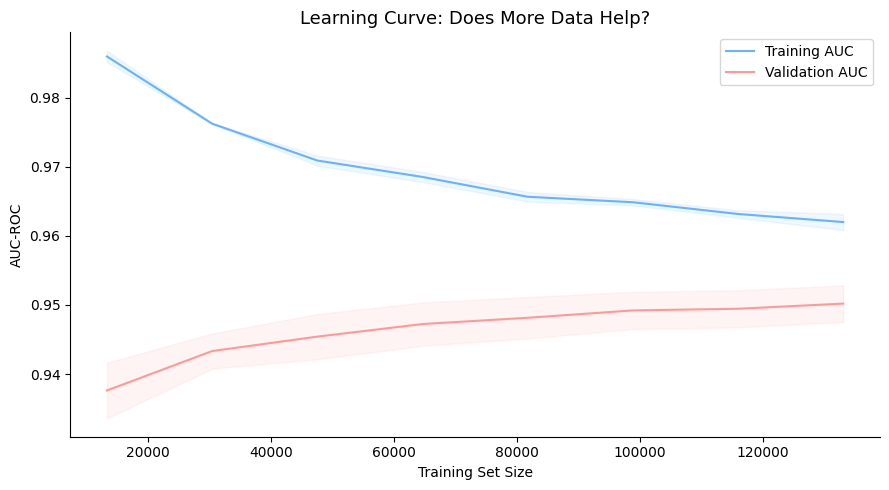

final training AUC:   0.9620
final validation AUC: 0.9502
gap (overfitting indicator): 0.0118


In [17]:
# using n_estimators=100 to keep this faster
print('computing learning curve, this takes a few minutes...')

train_sizes, train_scores, val_scores = learning_curve(
    XGBClassifier(
        scale_pos_weight=scale, n_estimators=100,
        max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric='auc', verbosity=0
    ),
    X_encoded, y,
    cv=3, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, label='Training AUC',   color='#66b3ff')
plt.plot(train_sizes, val_mean,   label='Validation AUC', color='#ff9999')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#66b3ff')
plt.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.1, color='#ff9999')
plt.xlabel('Training Set Size')
plt.ylabel('AUC-ROC')
plt.title('Learning Curve: Does More Data Help?', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../plots/plot_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'final training AUC:   {train_mean[-1]:.4f}')
print(f'final validation AUC: {val_mean[-1]:.4f}')
print(f'gap (overfitting indicator): {train_mean[-1] - val_mean[-1]:.4f}')

## 11. Confusion Matrix

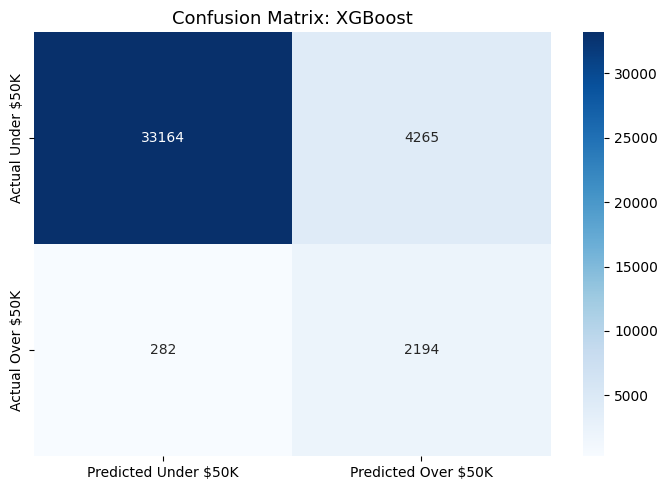

True Negatives  (correct under $50K): 33,164
False Positives (low earner targeted): 4,265
False Negatives (high earner missed):  282
True Positives  (correct over $50K):  2,194


In [18]:
# false negative = missed a high earner = lost marketing opportunity
# false positive = flagged a low earner = wasted ad spend

cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Under $50K', 'Predicted Over $50K'],
            yticklabels=['Actual Under $50K', 'Actual Over $50K'])
plt.title('Confusion Matrix: XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correct under $50K): {tn:,}')
print(f'False Positives (low earner targeted): {fp:,}')
print(f'False Negatives (high earner missed):  {fn:,}')
print(f'True Positives  (correct over $50K):  {tp:,}')

## 12. Calibration Check and Correction

Checking if the model probability scores are reliable.
If the model says 70% confidence, are 70% of those actually high earners?
XGBoost on imbalanced data tends to be overconfident.
Applying Platt scaling to correct this.

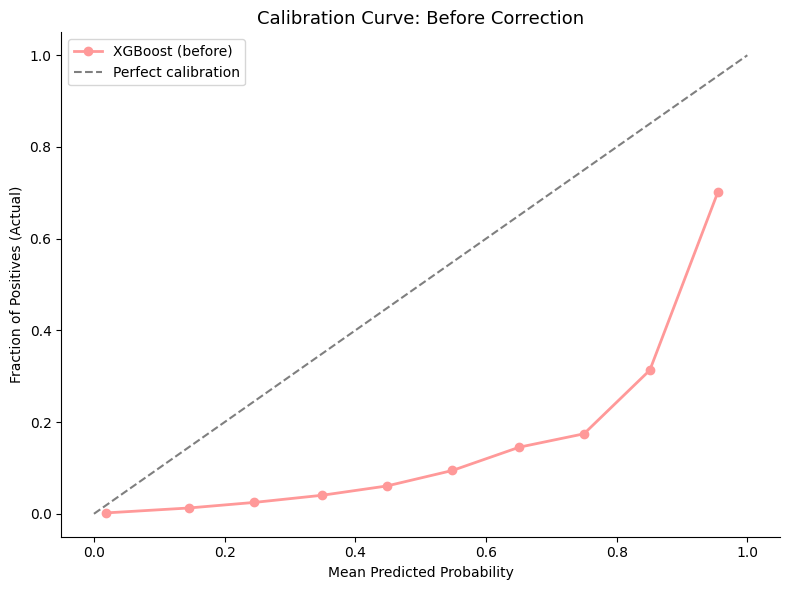

line below diagonal = model is overconfident
applying Platt scaling to correct this...


In [19]:
# checking calibration before correction
prob_true, prob_pred = calibration_curve(
    y_test, xgb_probs, n_bins=10, strategy='uniform'
)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', color='#ff9999',
         label='XGBoost (before)', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Calibration Curve: Before Correction', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../plots/plot_calibration_before.png', dpi=150, bbox_inches='tight')
plt.show()

print('line below diagonal = model is overconfident')
print('applying Platt scaling to correct this...')

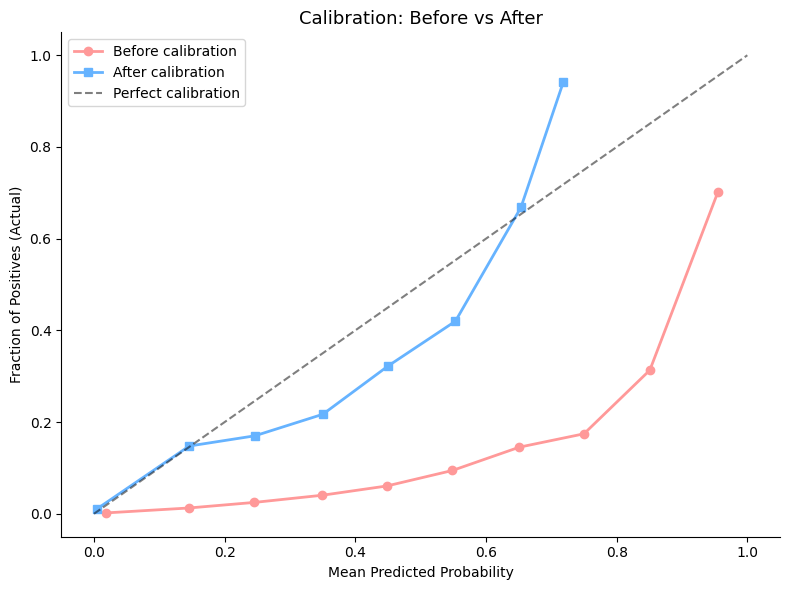

AUC before calibration: 0.9546
AUC after calibration:  0.9546
calibration improved probability reliability without affecting AUC
using calibrated model for all remaining analysis


In [20]:
# applying Platt scaling calibration
calibrated_xgb = CalibratedClassifierCV(xgb, cv='prefit', method='sigmoid')
calibrated_xgb.fit(X_train_scaled, y_train)

cal_probs = calibrated_xgb.predict_proba(X_test_scaled)[:, 1]
cal_auc   = roc_auc_score(y_test, cal_probs)

prob_true_cal, prob_pred_cal = calibration_curve(
    y_test, cal_probs, n_bins=10, strategy='uniform'
)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred,     prob_true,     marker='o', color='#ff9999',
         label='Before calibration', linewidth=2)
plt.plot(prob_pred_cal, prob_true_cal, marker='s', color='#66b3ff',
         label='After calibration',  linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Calibration: Before vs After', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../plots/plot_calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC before calibration: {xgb_auc:.4f}')
print(f'AUC after calibration:  {cal_auc:.4f}')
print('calibration improved probability reliability without affecting AUC')
print('using calibrated model for all remaining analysis')

# updating probabilities to use calibrated version
xgb_probs = cal_probs

## 13. Business Threshold Tuning

Default threshold of 0.5 is not always right for business.
Giving the client a concrete table to choose their own tradeoff
based on their marketing budget and goals.

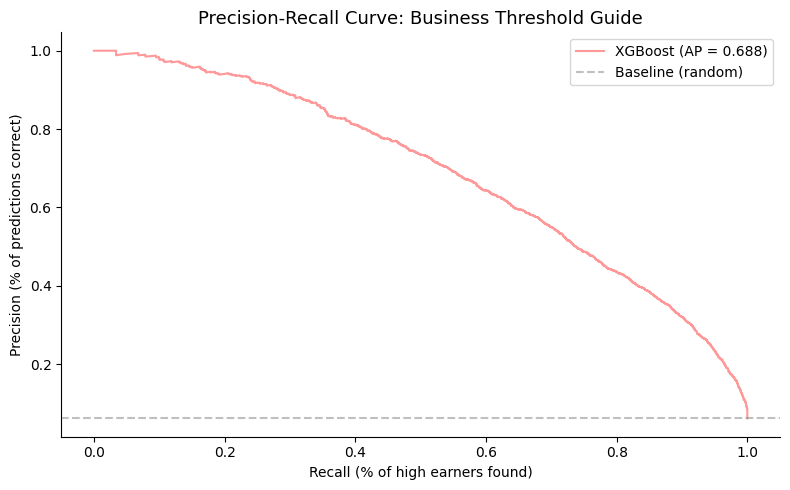

In [21]:
# precision-recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, xgb_probs)
avg_precision = average_precision_score(y_test, xgb_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall_vals, precision_vals, color='#ff9999',
         label=f'XGBoost (AP = {avg_precision:.3f})')
plt.axhline(y=0.062, color='gray', linestyle='--', alpha=0.5, label='Baseline (random)')
plt.xlabel('Recall (% of high earners found)')
plt.ylabel('Precision (% of predictions correct)')
plt.title('Precision-Recall Curve: Business Threshold Guide', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../plots/plot_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# threshold analysis table for the client
threshold_analysis = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds_t = (xgb_probs >= t).astype(int)
    if preds_t.sum() == 0:
        continue
    threshold_analysis.append({
        'Threshold':      t,
        'Precision':      round(precision_score(y_test, preds_t, zero_division=0), 3),
        'Recall':         round(recall_score(y_test, preds_t, zero_division=0), 3),
        'F1':             round(f1_score(y_test, preds_t, zero_division=0), 3),
        'People flagged': int(preds_t.sum())
    })

thresh_df = pd.DataFrame(threshold_analysis)
print('threshold analysis for business use:')
print(thresh_df.to_string(index=False))
print('\nlower threshold = more high earners found, more false positives')
print('higher threshold = fewer false positives, more high earners missed')

threshold analysis for business use:
 Threshold  Precision  Recall    F1  People flagged
       0.2      0.454   0.779 0.574            4253
       0.3      0.513   0.729 0.602            3518
       0.4      0.580   0.672 0.623            2873
       0.5      0.653   0.589 0.619            2235
       0.6      0.763   0.467 0.580            1516
       0.7      0.941   0.201 0.331             528

lower threshold = more high earners found, more false positives
higher threshold = fewer false positives, more high earners missed


## 14. Feature Importance

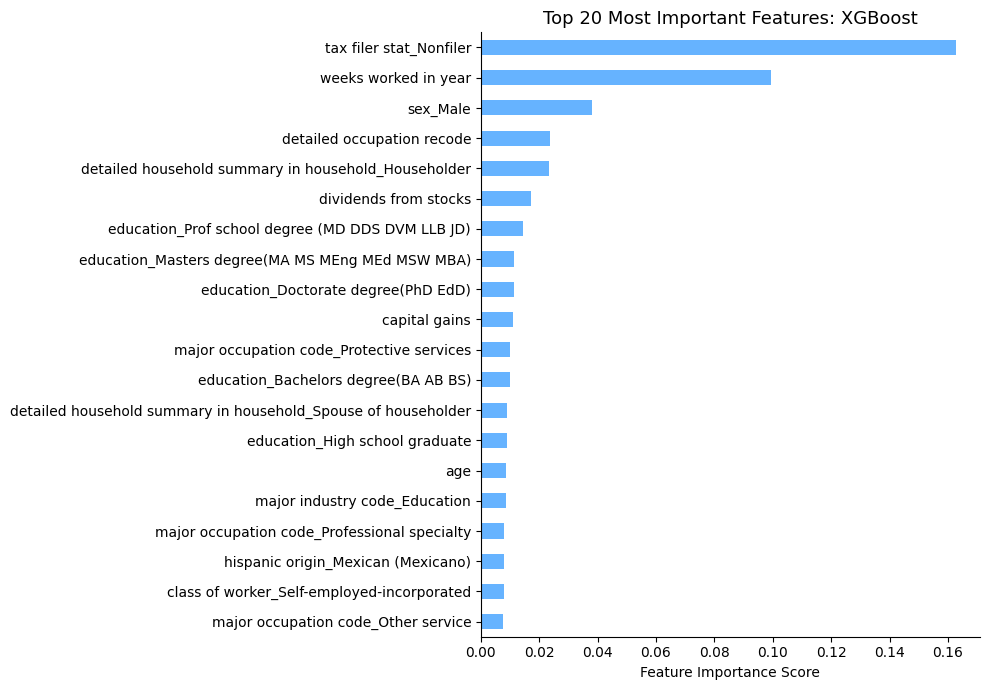

In [23]:
# top 20 most important features
feat_imp = pd.Series(
    xgb.feature_importances_, index=X_encoded.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
feat_imp.sort_values().plot(kind='barh', color='#66b3ff')
plt.title('Top 20 Most Important Features: XGBoost', fontsize=13)
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('../plots/plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

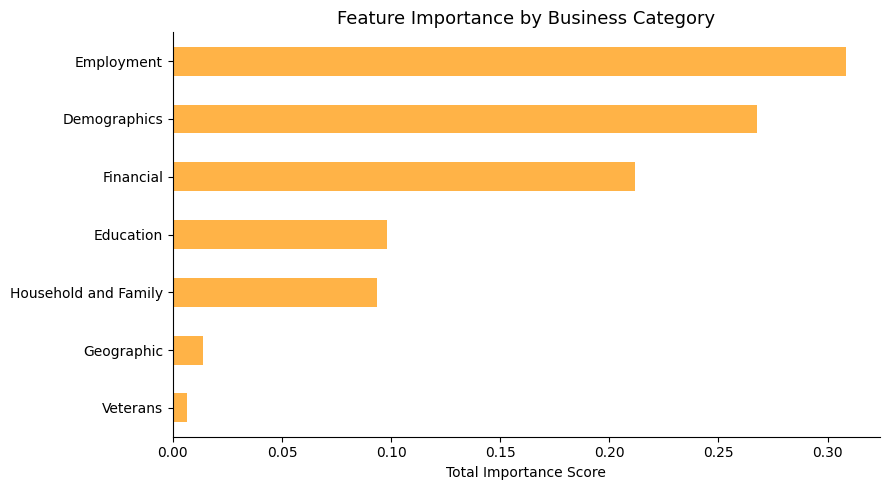

Employment              0.3086
Demographics            0.2677
Financial               0.2119
Education               0.0982
Household and Family    0.0935
Geographic              0.0137
Veterans                0.0064
dtype: float32


In [24]:
# grouping importance by business category
# more useful for the client than a raw feature list

feature_groups = {
    'Demographics':         ['age', 'sex', 'race', 'hispanic origin', 'citizenship',
                             'country of birth self', 'country of birth father', 'country of birth mother'],
    'Employment':           ['class of worker', 'major occupation code', 'major industry code',
                             'detailed occupation recode', 'detailed industry recode',
                             'full or part time employment stat', 'weeks worked in year',
                             'wage per hour', 'num persons worked for employer',
                             'own business or self employed', 'member of a labor union',
                             'reason for unemployment'],
    'Education':            ['education', 'enroll in edu inst last wk'],
    'Financial':            ['capital gains', 'capital losses', 'dividends from stocks',
                             'tax filer stat', 'has_capital_gains', 'has_dividends'],
    'Household and Family': ['marital stat', 'family members under 18',
                             'detailed household and family stat',
                             'detailed household summary in household'],
    'Geographic':           ['region of previous residence', 'live in this house 1 year ago'],
    'Veterans':             ["fill inc questionnaire for veteran's admin", 'veterans benefits']
}

all_importances  = pd.Series(xgb.feature_importances_, index=X_encoded.columns)
group_importance = {}
for group, features in feature_groups.items():
    matched = [col for col in X_encoded.columns
               if any(col == f or col.startswith(f + '_') for f in features)]
    group_importance[group] = all_importances[matched].sum()

group_imp = pd.Series(group_importance).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
group_imp.plot(kind='barh', color='#ffb347')
plt.title('Feature Importance by Business Category', fontsize=13)
plt.xlabel('Total Importance Score')
plt.tight_layout()
plt.savefig('../plots/plot_importance_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(group_imp.sort_values(ascending=False).round(4))

## 15. SHAP Analysis

SHAP explains WHY the model made each individual prediction.
Regular feature importance tells you which features matter overall.
SHAP tells you exactly how each feature pushed a specific prediction up or down.
This is what makes the model explainable to the client.

In [25]:
# using 2000 rows to keep this fast
print('computing SHAP values...')

X_sample = pd.DataFrame(
    X_test_scaled, columns=X_encoded.columns
).sample(n=2000, random_state=42)

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

print('done')

computing SHAP values...
done


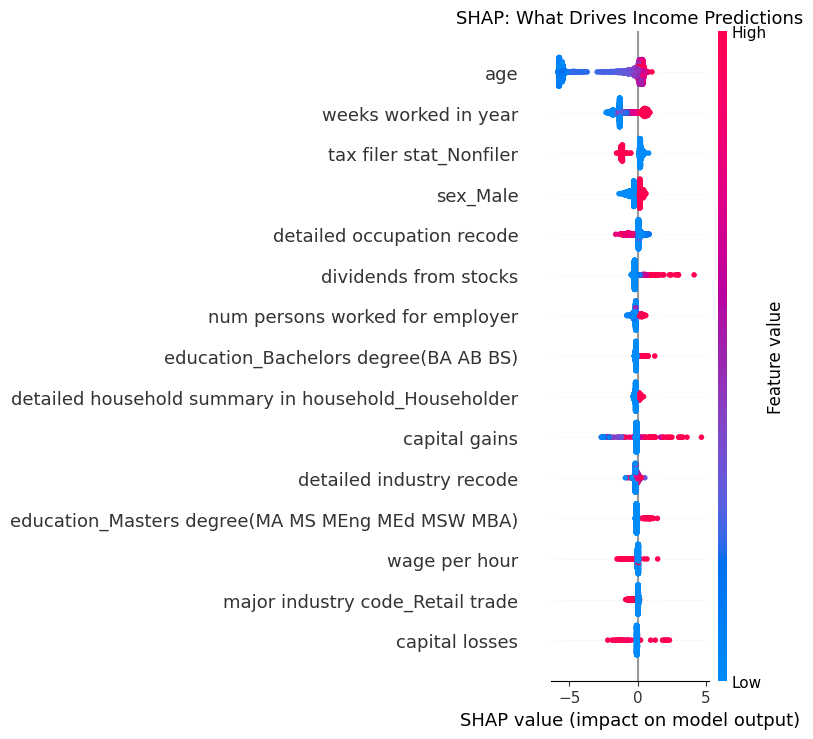

In [26]:
# SHAP summary plot
# red = high feature value, blue = low feature value
# dots to the right = pushed prediction toward over $50K
# dots to the left  = pushed prediction toward under $50K

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title('SHAP: What Drives Income Predictions', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/plot_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# explaining one specific high income prediction
# shows the client exactly why a person was flagged as high earner

sample_probs    = xgb.predict_proba(X_sample)[:, 1]
high_earner_idx = sample_probs.argmax()

print(f'example: person flagged as high earner')
print(f'model confidence: {sample_probs[high_earner_idx]:.1%}')

person_shap = pd.Series(
    shap_values[high_earner_idx], index=X_sample.columns
).sort_values(ascending=False)

print('\ntop factors pushing toward high income:')
print(person_shap.head(10).round(3))
print('\nfactors pushing toward low income:')
print(person_shap.tail(5).round(3))

example: person flagged as high earner
model confidence: 99.9%

top factors pushing toward high income:
capital gains                                       3.011
dividends from stocks                               0.966
education_Masters degree(MA MS MEng MEd MSW MBA)    0.708
weeks worked in year                                0.574
detailed occupation recode                          0.417
sex_Male                                            0.384
age                                                 0.357
num persons worked for employer                     0.313
tax filer stat_Nonfiler                             0.252
member of a labor union_Not in universe             0.109
dtype: float32

factors pushing toward low income:
education_Bachelors degree(BA AB BS)                             -0.062
citizenship_Native- Born in the United States                    -0.086
country of birth father_Poland                                   -0.087
live in this house 1 year ago_Not in universe und

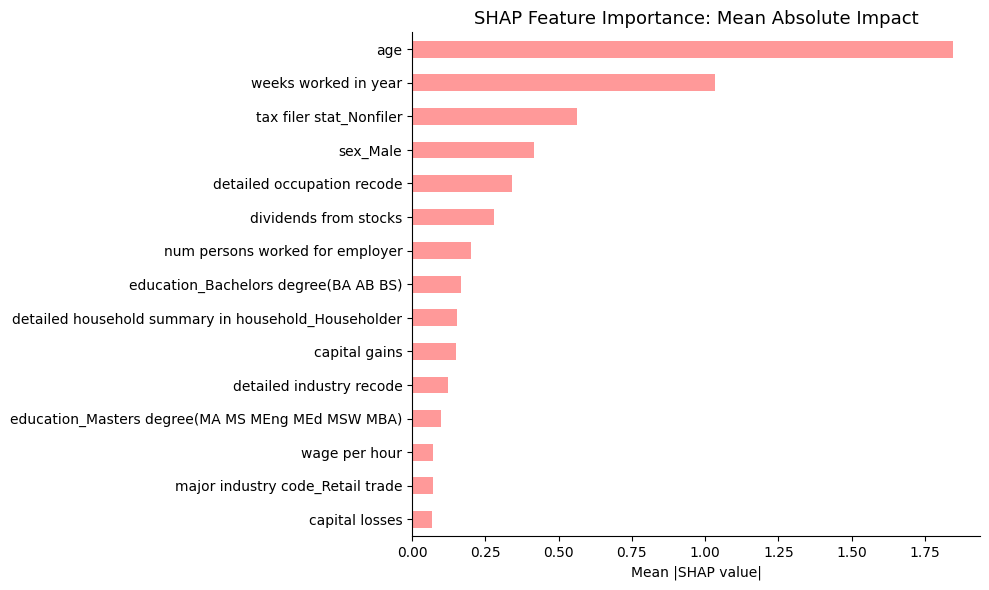

In [28]:
# SHAP mean absolute importance
# cleaner version of feature importance using SHAP values

shap_mean = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_sample.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
shap_mean.sort_values().plot(kind='barh', color='#ff9999')
plt.title('SHAP Feature Importance: Mean Absolute Impact', fontsize=13)
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig('../plots/plot_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. ROI Framing for the Client

Translating model performance into actual business value.
How many more high earners does the model find vs random targeting?

In [29]:
budget_sizes = [1000, 5000, 10000, 50000]
true_rate    = y_test.mean()
model_prec   = precision_score(
    y_test, (xgb_probs >= 0.5).astype(int), zero_division=0
)

print('ROI: model targeting vs random targeting')
print(f'baseline high earner rate: {true_rate:.1%}')
print(f'model precision at 0.5:    {model_prec:.1%}')
print()
print(f'{"Budget":>10} | {"Random":>15} | {"Model":>15} | {"Gain":>8}')
print('-' * 58)
for b in budget_sizes:
    rnd  = int(b * true_rate)
    mdl  = int(b * model_prec)
    gain = mdl / max(rnd, 1)
    print(f'{b:>10,} | {rnd:>12,} hits | {mdl:>12,} hits | {gain:>6.1f}x')

ROI: model targeting vs random targeting
baseline high earner rate: 6.2%
model precision at 0.5:    65.3%

    Budget |          Random |           Model |     Gain
----------------------------------------------------------
     1,000 |           62 hits |          652 hits |   10.5x
     5,000 |          310 hits |        3,263 hits |   10.5x
    10,000 |          620 hits |        6,527 hits |   10.5x
    50,000 |        3,102 hits |       32,639 hits |   10.5x


## 17. Fairness Check

Checking if the model performs equally well across demographic groups.
If AUC is much lower for one group, the model may be less reliable
for that group in marketing targeting.

In [30]:
print('fairness check: model performance by demographic group')
print('=' * 55)

# getting original unencoded test data for group labels
df_test = df.iloc[y_test.index]

# check by sex
print('\nAUC by sex:')
for group in df_test['sex'].unique():
    mask = df_test['sex'] == group
    if mask.sum() < 50:
        continue
    group_auc  = roc_auc_score(y_test[mask], xgb_probs[mask])
    group_rate = y_test[mask].mean()
    print(f'  {group:10} | AUC: {group_auc:.4f} | high earner rate: {group_rate:.1%}')

# check by race
print('\nAUC by race:')
for group in df_test['race'].unique():
    mask = df_test['race'] == group
    if mask.sum() < 50:
        continue
    group_auc  = roc_auc_score(y_test[mask], xgb_probs[mask])
    group_rate = y_test[mask].mean()
    print(f'  {group:35} | AUC: {group_auc:.4f} | high earner rate: {group_rate:.1%}')

# check by education group
print('\nAUC by education group:')
edu_groups = {
    'Advanced degree':      ['Prof school degree (MD DDS DVM LLB JD)',
                             'Doctorate degree(PhD EdD)',
                             'Masters degree(MA MS MEng MEd MSW MBA)'],
    'Bachelors degree':     ['Bachelors degree(BA AB BS)'],
    'Some college':         ['Associates degree-academic program',
                             'Associates degree-occup /vocational',
                             'Some college but no degree'],
    'High school or below': ['High school graduate', '12th grade no diploma',
                             '11th grade', '10th grade', '9th grade',
                             '7th and 8th grade', '5th or 6th grade',
                             '1st 2nd 3rd or 4th grade',
                             'Less than 1st grade', 'Children']
}

for group_name, edu_list in edu_groups.items():
    mask = df_test['education'].isin(edu_list)
    if mask.sum() < 50:
        continue
    group_auc  = roc_auc_score(y_test[mask], xgb_probs[mask])
    group_rate = y_test[mask].mean()
    print(f'  {group_name:25} | AUC: {group_auc:.4f} | high earner rate: {group_rate:.1%}')

print('\n' + '=' * 55)
print('NOTE: lower AUC for advanced degree holders suggests')
print('the model is less reliable for high education segments')
print('the retail client should be aware of this limitation')

fairness check: model performance by demographic group

AUC by sex:
  Female     | AUC: 0.9423 | high earner rate: 2.5%
  Male       | AUC: 0.9472 | high earner rate: 10.2%

AUC by race:
  Amer Indian Aleut or Eskimo         | AUC: 0.9417 | high earner rate: 2.3%
  White                               | AUC: 0.9536 | high earner rate: 6.7%
  Other                               | AUC: 0.9622 | high earner rate: 1.9%
  Black                               | AUC: 0.9538 | high earner rate: 2.5%
  Asian or Pacific Islander           | AUC: 0.9501 | high earner rate: 8.2%

AUC by education group:
  Advanced degree           | AUC: 0.8942 | high earner rate: 37.3%
  Bachelors degree          | AUC: 0.8954 | high earner rate: 20.1%
  Some college              | AUC: 0.9050 | high earner rate: 7.0%
  High school or below      | AUC: 0.9495 | high earner rate: 1.6%

NOTE: lower AUC for advanced degree holders suggests
the model is less reliable for high education segments
the retail client should

## 18. Prediction Function

A simple function the client can call with a new person's data
to get back a prediction, probability, and confidence level.
This is how the model would be used in practice.

In [31]:
def predict_income(person_data, model, scaler, feature_columns):
    """
    Predict income class for a new person.
    person_data: dict with feature names and values
    returns: prediction, probability, and confidence level
    """
    person_df      = pd.DataFrame([person_data])
    person_encoded = pd.get_dummies(person_df)
    person_encoded = person_encoded.reindex(columns=feature_columns, fill_value=0)
    person_scaled  = scaler.transform(person_encoded)
    prob           = model.predict_proba(person_scaled)[0][1]
    prediction     = int(prob >= 0.5)
    confidence     = 'High' if prob >= 0.7 else 'Medium' if prob >= 0.4 else 'Low'

    return {
        'prediction':  'Over $50K' if prediction == 1 else 'Under $50K',
        'probability': round(prob, 3),
        'confidence':  confidence
    }

# testing with a strong high earner profile
strong_high_earner = {
    'age': 48,
    'education': 'Masters degree(MA MS MEng MEd MSW MBA)',
    'sex': 'Male',
    'marital stat': 'Married-civilian spouse present',
    'class of worker': 'Self-employed-incorporated',
    'weeks worked in year': 52,
    'capital gains': 10000,
    'capital losses': 0,
    'dividends from stocks': 5000,
    'has_capital_gains': 1,
    'has_dividends': 1,
    'major occupation code': 'Professional specialty',
    'tax filer stat': 'Joint one under 65 & one 65+',
    'num persons worked for employer': 6,
    'wage per hour': 0,
    'race': 'White',
    'full or part time employment stat': 'Full-time schedules'
}

# testing with a strong low earner profile
strong_low_earner = {
    'age': 22,
    'education': 'High school graduate',
    'sex': 'Female',
    'marital stat': 'Never married',
    'class of worker': 'Private',
    'weeks worked in year': 20,
    'capital gains': 0,
    'capital losses': 0,
    'dividends from stocks': 0,
    'has_capital_gains': 0,
    'has_dividends': 0,
    'tax filer stat': 'Nonfiler',
    'num persons worked for employer': 1,
    'wage per hour': 0,
    'race': 'White',
    'full or part time employment stat': 'Part-time for non-economic reasons usually full-time'
}

r1 = predict_income(strong_high_earner, calibrated_xgb, scaler, X_encoded.columns)
r2 = predict_income(strong_low_earner,  calibrated_xgb, scaler, X_encoded.columns)

print('strong high earner profile:')
print(f'  prediction:  {r1["prediction"]}')
print(f'  probability: {r1["probability"]}')
print(f'  confidence:  {r1["confidence"]}')
print('\nstrong low earner profile:')
print(f'  prediction:  {r2["prediction"]}')
print(f'  probability: {r2["probability"]}')
print(f'  confidence:  {r2["confidence"]}')

strong high earner profile:
  prediction:  Over $50K
  probability: 0.722
  confidence:  High

strong low earner profile:
  prediction:  Under $50K
  probability: 0.001
  confidence:  Low


## 19. Save Everything

In [32]:
# saving calibrated model, scaler, and preprocessed data
joblib.dump(calibrated_xgb, '../data/xgb_model_calibrated.pkl')
joblib.dump(xgb,            '../data/xgb_model.pkl')
joblib.dump(scaler,         '../data/scaler.pkl')

X_encoded.to_csv('../data/X_preprocessed.csv', index=False)
y.to_csv('../data/y_labels.csv', index=False)

print('saved:')
print('  data/xgb_model_calibrated.pkl')
print('  data/xgb_model.pkl')
print('  data/scaler.pkl')
print('  data/X_preprocessed.csv')
print('  data/y_labels.csv')
print('\nready for notebook 03: segmentation')

saved:
  data/xgb_model_calibrated.pkl
  data/xgb_model.pkl
  data/scaler.pkl
  data/X_preprocessed.csv
  data/y_labels.csv

ready for notebook 03: segmentation
